# Methane-d13C Two-Box Demo

Synthetic demonstration of `paleobeasts.signal_models.MethaneD13C`.

This notebook focuses on synthetic validation cases rather than external observational files.

## Parameters and Variables

Core parameters:
- `source_strengths`: total source strengths in Tg/yr for `biogenic`, `pyrogenic`, `geological`, `fossil`
- `source_signatures`: source d13C values in permil vs VPDB for the same categories
- `source_shares`: NH source fractions for each category
- `sink_inverse_lifetimes`: inverse lifetimes in 1/yr for `oh`, `soil`, `stratosphere`
- `sink_kies`: kinetic isotope effects for the three sinks
- `tau_ex`: interhemispheric exchange timescale in years

Integrated state variables:
- `ch4_12_nh`, `ch4_12_sh`, `ch4_13_nh`, `ch4_13_sh`

Diagnostics:
- `ch4_total_nh`, `ch4_total_sh`
- `delta13c_nh`, `delta13c_sh`
- total and per-category NH/SH sources

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from paleobeasts.signal_models import MethaneD13C


def default_y0(total=700.0, delta=-47.0):
    ch4_12, ch4_13 = MethaneD13C.split_total_and_delta(total, delta)
    return [ch4_12, ch4_12, ch4_13, ch4_13]

## 1. Steady-State Control

With constant sources and sinks, the model should approach a stable NH/SH methane burden and d13C.

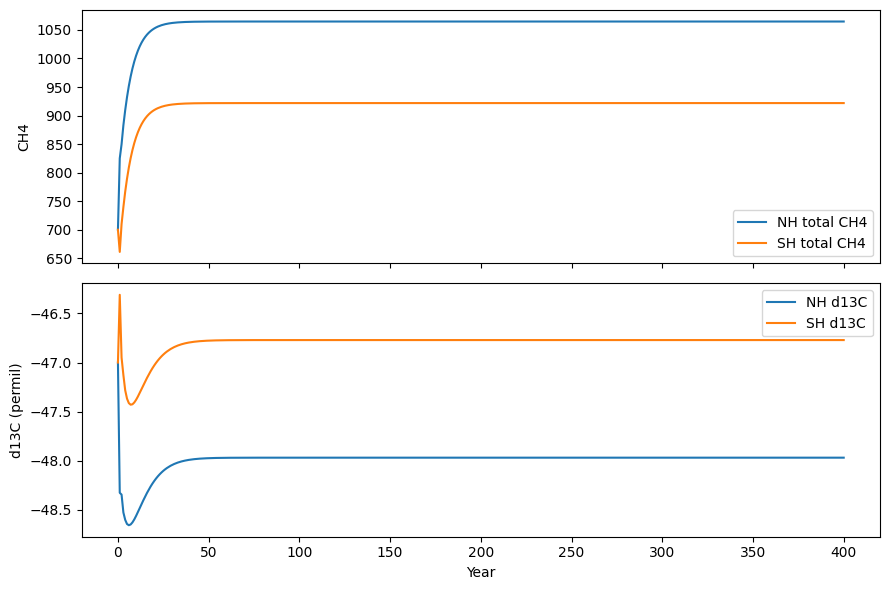

In [2]:
steady = MethaneD13C()
steady.integrate(t_span=(0, 400), y0=default_y0(), method='euler', kwargs={'dt': 1.0})

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax[0].plot(steady.time, steady.diagnostic_variables['ch4_total_nh'], label='NH total CH4')
ax[0].plot(steady.time, steady.diagnostic_variables['ch4_total_sh'], label='SH total CH4')
ax[0].set_ylabel('CH4')
ax[0].legend()

ax[1].plot(steady.time, steady.diagnostic_variables['delta13c_nh'], label='NH d13C')
ax[1].plot(steady.time, steady.diagnostic_variables['delta13c_sh'], label='SH d13C')
ax[1].set_ylabel('d13C (permil)')
ax[1].set_xlabel('Year')
ax[1].legend()
plt.tight_layout()

## 2. Symmetric Hemisphere Check

If every category is distributed 50/50 between hemispheres and the initial state is symmetric, NH and SH should remain identical.

In [3]:
equal_shares = {category: 0.5 for category in ('biogenic', 'pyrogenic', 'geological', 'fossil')}
symmetric = MethaneD13C(source_shares=equal_shares)
symmetric.integrate(t_span=(0, 100), y0=default_y0(), method='euler', kwargs={'dt': 1.0})

print('Max NH-SH CH4 difference:', np.max(np.abs(symmetric.diagnostic_variables['ch4_total_nh'] - symmetric.diagnostic_variables['ch4_total_sh'])))
print('Max NH-SH d13C difference:', np.max(np.abs(symmetric.diagnostic_variables['delta13c_nh'] - symmetric.diagnostic_variables['delta13c_sh'])))

Max NH-SH CH4 difference: 0.0
Max NH-SH d13C difference: 0.0


## 3. Single-Source Sanity Suite

Pyrogenic emissions should yield the most enriched atmospheric d13C, while biogenic emissions should be the most depleted.

In [4]:
single_source_results = {}
for category in ('biogenic', 'pyrogenic', 'geological', 'fossil'):
    strengths = {key: 0.0 for key in ('biogenic', 'pyrogenic', 'geological', 'fossil')}
    strengths[category] = 100.0
    model = MethaneD13C(source_strengths=strengths)
    model.integrate(t_span=(0, 250), y0=default_y0(total=200.0), method='euler', kwargs={'dt': 1.0})
    single_source_results[category] = np.mean(model.diagnostic_variables['delta13c_nh'][-50:])

single_source_results

{'biogenic': np.float64(-54.90961936867161),
 'pyrogenic': np.float64(-15.709278180866752),
 'geological': np.float64(-32.390727365587516),
 'fossil': np.float64(-32.390727365587516)}

## 4. Synthetic Inversion Round-Trip

Generate synthetic observations from known biogenic and pyrogenic histories, then recover those histories with the inversion helper.

In [5]:
years = np.arange(0, 201, 1.0)
shares = MethaneD13C.default_source_shares()

bio = lambda t: 220.0 + 12.0 * np.sin(2.0 * np.pi * t / 80.0)
pyro = lambda t: 28.0 + 4.0 * np.cos(2.0 * np.pi * t / 55.0)

spinup = MethaneD13C(source_strengths={'biogenic': bio(0.0), 'pyrogenic': pyro(0.0), 'geological': 44.0, 'fossil': 0.0})
spinup.integrate(t_span=(0, 400), y0=default_y0(), method='euler', kwargs={'dt': 1.0})
y0 = [
    spinup.state_variables['ch4_12_nh'][-1],
    spinup.state_variables['ch4_12_sh'][-1],
    spinup.state_variables['ch4_13_nh'][-1],
    spinup.state_variables['ch4_13_sh'][-1],
]

synthetic = MethaneD13C(source_strengths={'biogenic': bio, 'pyrogenic': pyro, 'geological': 44.0, 'fossil': 0.0})
synthetic.integrate(t_span=(0, 200), y0=y0, method='euler', kwargs={'dt': 1.0})

inversion = synthetic.invert_biogenic_pyrogenic(
    synthetic.time,
    synthetic.diagnostic_variables['ch4_total_nh'],
    synthetic.diagnostic_variables['ch4_total_sh'],
    synthetic.diagnostic_variables['delta13c_nh'],
    synthetic.diagnostic_variables['delta13c_sh'],
)

expected_bio_nh = np.array([bio(t) for t in years]) * shares['biogenic']
expected_py_nh = np.array([pyro(t) for t in years]) * shares['pyrogenic']

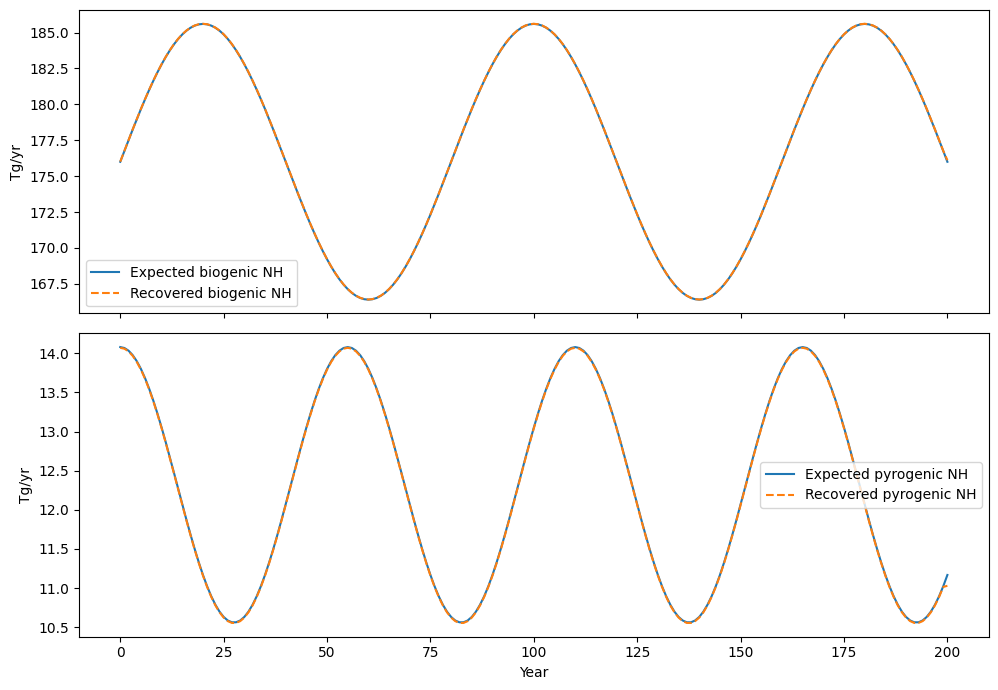

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(years, expected_bio_nh, label='Expected biogenic NH')
ax[0].plot(years, inversion.biogenic_nh, '--', label='Recovered biogenic NH')
ax[0].set_ylabel('Tg/yr')
ax[0].legend()

ax[1].plot(years, expected_py_nh, label='Expected pyrogenic NH')
ax[1].plot(years, inversion.pyrogenic_nh, '--', label='Recovered pyrogenic NH')
ax[1].set_ylabel('Tg/yr')
ax[1].set_xlabel('Year')
ax[1].legend()
plt.tight_layout()

## 5. Optional Monte Carlo Example

A lightweight uncertainty ensemble around the synthetic observations.

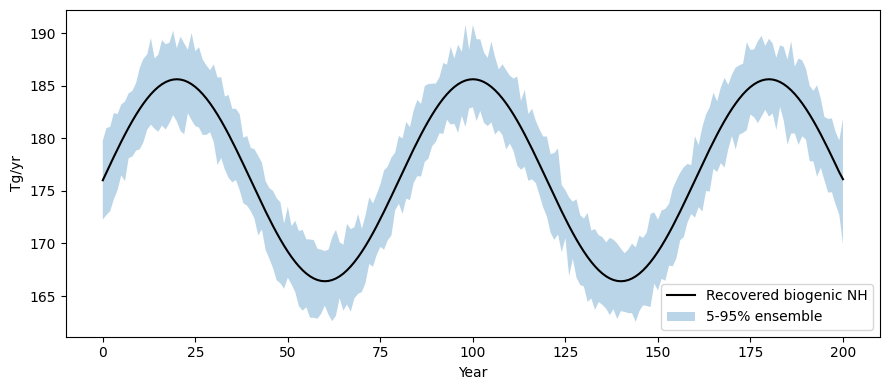

In [7]:
mc = synthetic.monte_carlo_inversion(
    synthetic.time,
    synthetic.diagnostic_variables['ch4_total_nh'],
    synthetic.diagnostic_variables['ch4_total_sh'],
    synthetic.diagnostic_variables['delta13c_nh'],
    synthetic.diagnostic_variables['delta13c_sh'],
    n_samples=50,
    random_seed=42,
)

plt.figure(figsize=(9, 4))
plt.plot(years, inversion.biogenic_nh, color='black', label='Recovered biogenic NH')
plt.fill_between(
    years,
    np.percentile(mc['biogenic_nh'], 5, axis=0),
    np.percentile(mc['biogenic_nh'], 95, axis=0),
    alpha=0.3,
    label='5-95% ensemble',
)
plt.xlabel('Year')
plt.ylabel('Tg/yr')
plt.legend()
plt.tight_layout()